In [17]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import cmocean as cmo 
import matplotlib as mpl 
# get dates

start_day = 6
end_day   = 30
isave = 360

model = xr.open_dataset("2024_June22_test.nc")


# Format days 
start_date = "2024-08-%02d 00:00" % start_day
end_date   = "2024-08-%02d 00:00" % end_day
nt = len(model.time.values)
dates = pd.date_range(start_date, end_date, freq="10s")
dates = dates[::isave]
dates = dates[0:nt]


colors = ["#a4c639", "#73c2fb", "#d1001c"]
print("there are %d times in the model" % len(model.time.values))


there are 527 times in the model


/tmp/ipykernel_598016/2324054773.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  model = xr.open_dataset("2024_June22_test.nc")


In [ ]:

##### Weber Point
site = "WP" 
date = "aug_13_2024"
fout = "/pscratch/sd/s/siennaw/stockton_field_data/microctd/%s_eps_%s_Layer=1000_wDiff.nc" % (site, date)

data = xr.open_dataset(fout)
data = data.sortby('time')
data = data.dropna(dim='time', how="all")

# Take surface layer 
surface_data = data.sel(z=slice(2, 0)) 
t = pd.to_datetime(surface_data.time.values)

kappa_1 = surface_data.kappa1.values
kappa_2 = surface_data.kappa2.values

k1 = np.nanmean(kappa_1, axis=1)
k2 = np.nanmean(kappa_2, axis=1)

# print(kz_av.values)
# kz_av = kz_av.rolling(time=2, center=True).mean()


/tmp/ipykernel_598016/2890370952.py:17: RuntimeWarning: Mean of empty slice
  k1 = np.nanmean(kappa_1, axis=1)
/tmp/ipykernel_598016/2890370952.py:18: RuntimeWarning: Mean of empty slice
  k2 = np.nanmean(kappa_2, axis=1)


<>:4: SyntaxWarning: invalid escape sequence '\k'
<>:4: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_598016/3844190219.py:4: SyntaxWarning: invalid escape sequence '\k'
  ax.plot(t, k1, 'o', color=colors[0], markersize=8, label="Measured MicroCTD $\kappa$")


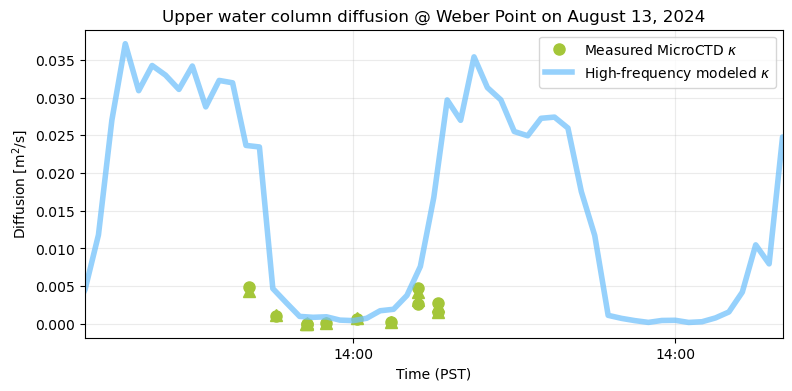

In [19]:
fig = plt.figure(figsize=(9,4))
ax = plt.gca()

ax.plot(t, k1, 'o', color=colors[0], markersize=8, label="Measured MicroCTD $\kappa$")
ax.plot(t, k2, '^', color=colors[0], markersize=8)

# Read in modeled diffusivity 
kz_ = model.Kz.sel(z=slice(2, 0)) 
kz_av = kz_.mean(dim="z") 

ax.plot(dates, kz_av.rolling(time=1).mean(), linewidth=4, alpha=0.75, color=colors[1], label=r"High-frequency modeled $\kappa$")
# ax.plot(dates, kz_av.rolling(time=100).mean(), '-', linewidth=2, alpha=0.85, color=colors[1], label=r"Smoothed modeled $\kappa$")


ax.set_xlim(pd.to_datetime("August 12, 2024 18:00"), pd.to_datetime("August 14, 2024 22:00"))
# format the dateimte axis with mdates
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(alpha=0.25, which="both")
ax.set_ylabel(r"Diffusion [m$^2$/s]")
ax.set_xlabel("Time (PST)")
ax.legend()
# ax.set_ylim(1e-5, 1e-1)
# ax.set_yscale('log')
ax.set_title("Upper water column diffusion @ Weber Point on August 13, 2024")
plt.show()


In [20]:
def format_date_ax(ax, days=2):
    """Format the x-axis of a plot with date labels."""
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=days))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%d %H:%M"))
    ax.grid(alpha=0.25, which="both")
    # plt.setp(ax.get_xticklabels(), rotation=10, ha='right')

(np.float64(19948.208333333332), np.float64(19948.916666666668))

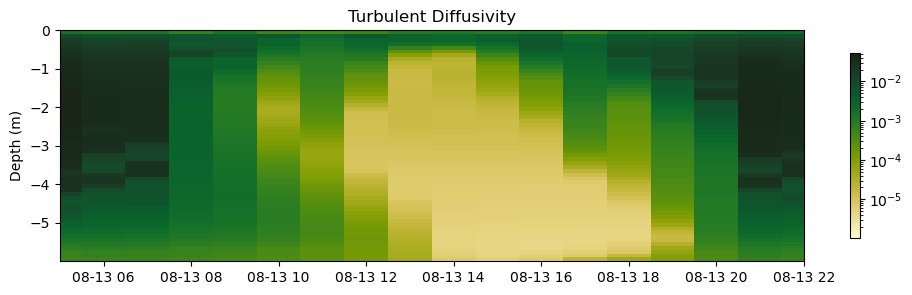

In [21]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(dates, -model.z, model['Kz'].values.T ,  cmap=cmo.cm.speed, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['Kz'].values.T , levels=20, cmap=cmo.cm.speed_r, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
# format_date_ax(ax, days=1)
plt.title('Turbulent Diffusivity')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 13, 2024 05:00"), pd.to_datetime("August 13, 2024 22:00"))


[-8.21099966e-04 -8.07299977e-04 -7.93499989e-04 -7.79700058e-04
 -7.65900069e-04 -7.52099964e-04 -7.38299976e-04 -7.24500045e-04
 -7.10700057e-04 -6.96900068e-04 -6.83099963e-04 -6.69299974e-04
 -6.55499985e-04 -6.41700055e-04 -6.27900066e-04 -6.14099961e-04
 -6.00299973e-04 -5.86500042e-04 -5.72700053e-04 -5.58900065e-04
 -5.45100018e-04 -5.31299971e-04 -5.17499982e-04 -5.03700052e-04
 -4.89900005e-04 -4.76100016e-04 -4.62299999e-04 -4.48500010e-04
 -4.34700021e-04 -4.20900004e-04 -4.07100015e-04 -3.93299997e-04
 -3.79500008e-04 -3.65700020e-04 -3.51900002e-04 -3.38100013e-04
 -3.24299996e-04 -3.10500007e-04 -2.96700018e-04 -2.82900000e-04
 -2.69100012e-04 -2.55300023e-04 -2.41500005e-04 -2.27700002e-04
 -2.13899999e-04 -2.00100010e-04 -1.86300007e-04 -1.72500004e-04
 -1.58700001e-04 -1.44899997e-04 -1.31099994e-04 -1.17300006e-04
 -1.03500002e-04 -8.96999991e-05 -7.59000031e-05 -6.20999999e-05
 -4.83000003e-05 -3.45000008e-05 -2.07000012e-05 -6.90000024e-06]


(np.float64(19948.208333333332), np.float64(19948.916666666668))

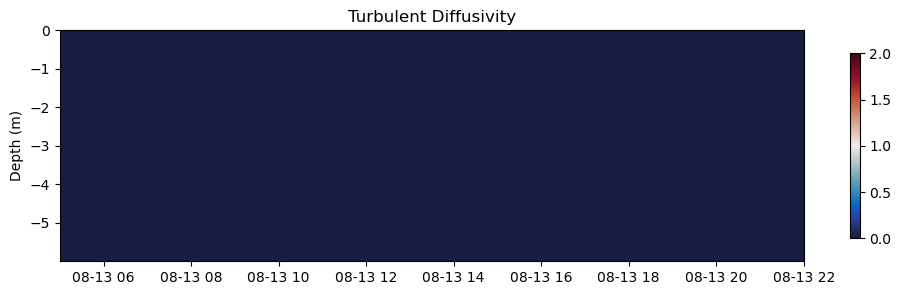

In [22]:
ws = 1.38e-4
z = -model.z.values
time_scale = z*ws 
print(time_scale)

fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot(111)
comparison = model['Kz'].values.T/time_scale[:,None]
c = ax.pcolormesh(dates, -model.z, comparison,  cmap=cmo.cm.balance, vmax=2, vmin=0) #, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['Kz'].values.T , levels=20, cmap=cmo.cm.speed_r, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
# format_date_ax(ax, days=1)
plt.title('Turbulent Diffusivity')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 13, 2024 05:00"), pd.to_datetime("August 13, 2024 22:00"))






Text(0, 0.5, 'Depth (m)')

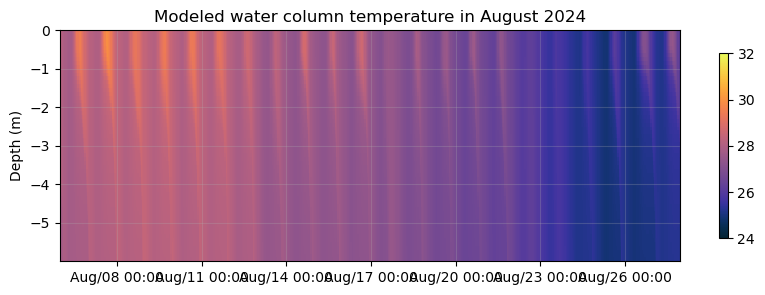

In [23]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(dates,-model.z, model['C'].values.T,  cmap=cmo.cm.thermal, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['C'].values.T , levels=20, cmap=cmo.cm.thermal, vmin=24, vmax=32) #, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
format_date_ax(ax, days=3)
plt.title('Modeled water column temperature in August 2024')
ax.set_ylabel('Depth (m)')

(np.float64(19948.208333333332), np.float64(19948.916666666668))

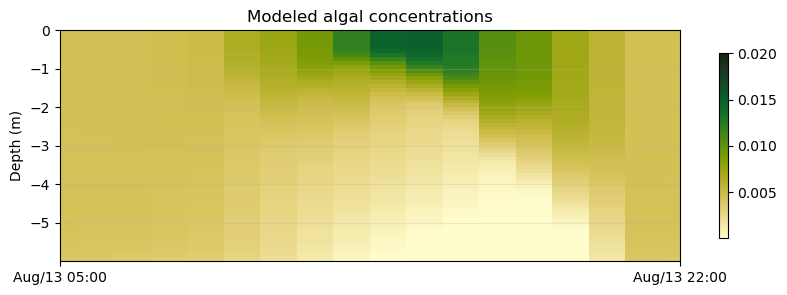

In [24]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(111)
c = ax.pcolormesh(dates, -model.z, model['algae1'].values.T ,  cmap=cmo.cm.speed, vmax=0.02) #, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
# c = ax.contourf(dates, -model.z, model['algae1'].values.T , levels=50, cmap=cmo.cm.algae, norm=mpl.colors.LogNorm()) #, vmin=1.5e-7, vmax=1.5e-7)
plt.colorbar(c, shrink=0.8)
format_date_ax(ax, days=3)
plt.title('Modeled algal concentrations')
ax.set_ylabel('Depth (m)')
ax.set_xlim(pd.to_datetime("August 13, 2024 05:00"), pd.to_datetime("August 13, 2024 22:00"))


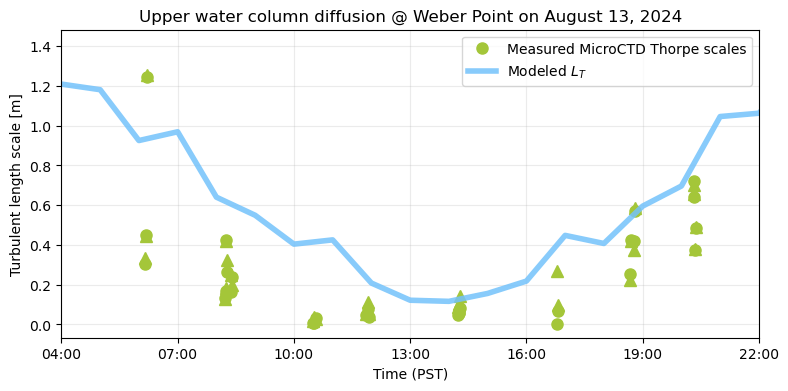

In [25]:
fig = plt.figure(figsize=(9,4))
ax = plt.gca()

date = "aug_13_2024"

##### Weber Point

# Take surface layer 
t = pd.to_datetime(surface_data.time.values)

L1 = np.nanmean(surface_data.thorpe1, axis=1)
L2 = np.nanmean(surface_data.thorpe2, axis=1)

ax.plot(t, L1, 'o', color=colors[0], markersize=8, label="Measured MicroCTD Thorpe scales")
ax.plot(t, L2, '^', color=colors[0], markersize=8)

modL = model.L.sel(z=slice(4, 0)) 
modL = modL.mean(dim="z") # np.nanmean(kz2.values, axis=0)
ax.plot(dates, modL, linewidth=4, alpha=0.85, color=colors[1], label="Modeled $L_T$")


ax.set_xlim(pd.to_datetime("August 13, 2024 04:00"), pd.to_datetime("August 13, 2024 22:00"))
# format the dateimte axis with mdates
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(alpha=0.25, which="both")
ax.set_ylabel("Turbulent length scale [m]")
ax.set_xlabel("Time (PST)")
ax.legend()
# ax.set_ylim(1e-5, 1e-1)
# ax.set_yscale('log')
ax.set_title("Upper water column diffusion @ Weber Point on August 13, 2024")
plt.show()



<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_598016/1179946942.py:3: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
/tmp/ipykernel_598016/1179946942.py:4: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
/tmp/ipykernel_598016/1179946942.py:5: SyntaxWarning: invalid escape sequence '\k'
  ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")


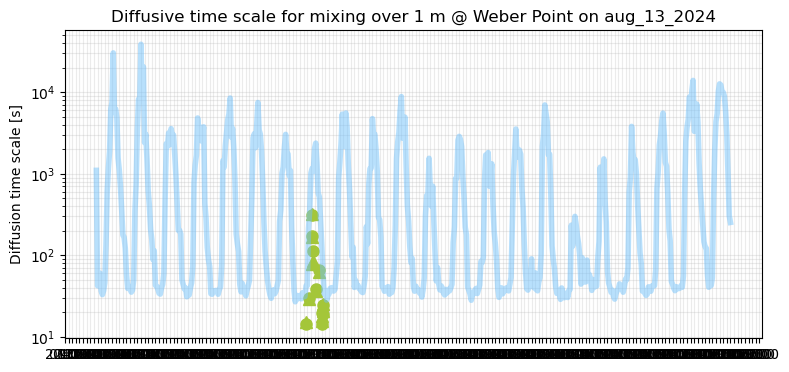

In [26]:
fig2 = plt.figure(figsize=(9,4))
ax2 = plt.gca()
ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")

# ax2.hlines(1/(diatom), t[0], t[-1], color=colors[2], label="1.4e-5 m/s", linestyle="--")
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(alpha=0.25, which="both")
# ax2.set_xlim(dates[175], dates[220])
ax2.set_yscale('log')
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_title("Diffusive time scale for mixing over 1 m @ Weber Point on %s" % date)
fig.savefig("aug_27.png")